
# Практика 11. Числові характеристики випадкової величини; закон великих чисел і ЦГТ симуляцією  
**Варіант 6 — Чернігів, λ = 0.22**  
**Студент: Войтович Богдан**  
**Група: IT-32**

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Фіксуємо генератор випадкових чисел для відтворюваності
rng = np.random.default_rng(6)

# Власний параметр λ для Чернігова
lam = 0.22
true_mean = 1 / lam
print(f"Теоретичне середнє E[X] = {true_mean:.3f} хв")


Теоретичне середнє E[X] = 4.545 хв


In [74]:
for n in [5, 50, 500, 20000]:
    sample = rng.exponential(scale=1/lam, size=n)
    sample_mean = sample.mean()
    abs_diff = abs(sample_mean - true_mean)
    print(f"n={n}: вибіркове середнє = {sample_mean:.3f}, абсолютна різниця = {abs_diff:.3f}")


n=5: вибіркове середнє = 2.498, абсолютна різниця = 2.047
n=50: вибіркове середнє = 4.549, абсолютна різниця = 0.003
n=500: вибіркове середнє = 4.453, абсолютна різниця = 0.093
n=20000: вибіркове середнє = 4.515, абсолютна різниця = 0.031


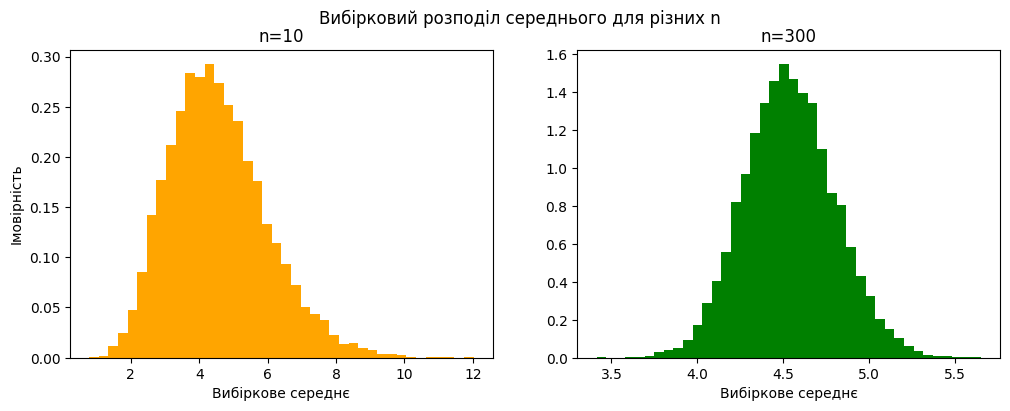

In [75]:
n_repeats = 10000
means_n10 = rng.exponential(scale=1/lam, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=1/lam, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(means_n10, bins=40, density=True, color='orange')
axes[0].set_title("n=10")
axes[0].set_xlabel("Вибіркове середнє")
axes[0].set_ylabel("Імовірність")
axes[1].hist(means_n300, bins=40, density=True, color='green')
axes[1].set_title("n=300")
axes[1].set_xlabel("Вибіркове середнє")
plt.suptitle("Вибірковий розподіл середнього для різних n")
plt.show()


In [76]:
ns = [10, 30, 100, 300]
print("n | Теоретична SE | Виміряна std")
for n in ns:
    se_theoretical = true_mean / np.sqrt(n)
    sample_means = rng.exponential(scale=1/lam, size=(n_repeats, n)).mean(axis=1)
    se_simulated = sample_means.std()
    print(f"{n} | {se_theoretical:.4f}       | {se_simulated:.4f}")


n | Теоретична SE | Виміряна std
10 | 1.4374       | 1.4364
30 | 0.8299       | 0.8386
100 | 0.4545       | 0.4610
300 | 0.2624       | 0.2638


In [77]:
se_25 = true_mean / np.sqrt(25)
se_100 = true_mean / np.sqrt(100)
print(f"SE при n=25: {se_25:.4f}")
print(f"SE при n=100: {se_100:.4f}")
print(f"Відношення SE_25 / SE_100 = {se_25/se_100:.2f}")


SE при n=25: 0.9091
SE при n=100: 0.4545
Відношення SE_25 / SE_100 = 2.00


Контрольні питання
Чим відрізняється те, що гарантує закон великих чисел, від того, що гарантує центральна гранична теорема?
Закон великих чисел відповідає на питання, куди прямує вибіркове середнє x̄ при збільшенні розміру вибірки n — воно збігається з теоретичним середнім генеральної сукупності. Центральна гранична теорема відповідає на питання, якою буде форма розподілу та його розкид для x̄, показуючи, що при великому n розподіл x̄ стає приблизно нормальним незалежно від форми початкового розподілу.

Чому в цій практиці вихідний розподіл (час очікування) обрано сильно скошеним, а не одразу нормальним?
Скошений експоненційний розподіл обрали, щоб було чітко видно, як початково нерівномірний і несиметричний розподіл змінюється на більш симетричний для вибіркових середніх при збільшенні n, що демонструє саме дію центральної граничної теореми. На нормальних даних це було би не так помітно.

Чому стандартна похибка зменшується пропорційно √n, а не n, і що це означає практично?
Стандартна похибка зменшується пропорційно 1/√n, бо вона визначає розкид вибіркових середніх. Практично це означає, що щоб зменшити похибку вдвічі, потрібно збільшити розмір вибірки в чотири рази — приріст спостережень потрібен нелінійно